<a href="https://colab.research.google.com/github/Shashank18ram/Data-Science/blob/main/KMeans_DBScan.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as  plt
from mpl_toolkits.mplot3d import Axes3D

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
df = pd.read_csv('/content/drive/MyDrive/Datasets/shopping_data.csv')
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [4]:
df_shopping = df.drop(columns=['CustomerID','Genre'],axis=1)
df_shopping.head()

,Age,Annual Income (k$),Spending Score (1-100)
0,19,15,39
1,21,15,81
2,20,16,6
3,23,16,77
4,31,17,40


In [5]:
#Step1 : lets scale the data
from sklearn.preprocessing import RobustScaler
scaler = RobustScaler()
RS = scaler.fit_transform(df_shopping)
RS
df_scaled_shopping = pd.DataFrame(RS,columns=df_shopping.columns)
df_scaled_shopping.head()

,Age,Annual Income (k$),Spending Score (1-100)
0,-0.839506,-1.273973,-0.287582
1,-0.740741,-1.273973,0.810458
2,-0.790123,-1.246575,-1.150327
3,-0.641975,-1.246575,0.705882
4,-0.246914,-1.219178,-0.261438


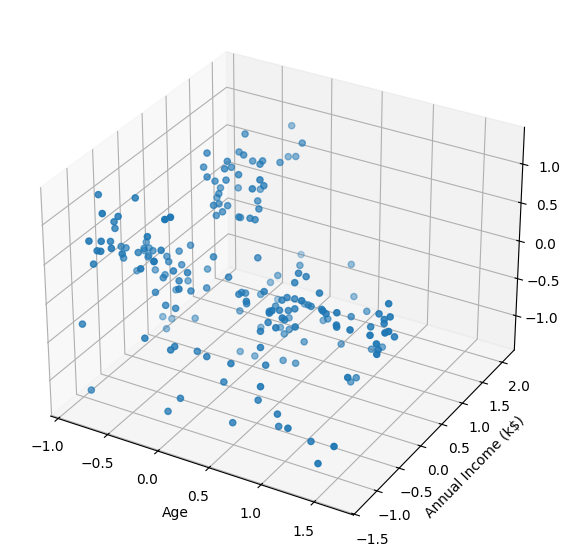

In [6]:
#Let me try a 3D plot of the data
fig = plt.figure(figsize=(10,7))
ax = fig.add_subplot(111,projection='3d')
ax.scatter(df_scaled_shopping['Age'],df_scaled_shopping['Annual Income (k$)'],df_scaled_shopping['Spending Score (1-100)'])
plt.xlabel('Age')
plt.ylabel('Annual Income (k$)')

plt.show()

In [7]:
# lets form the Clusters
from sklearn.cluster import KMeans


In [8]:
# form the cluster Object
kmeans = KMeans(n_clusters=5, random_state=42, n_init=30)

In [9]:
# Train the data
kmeans.fit(df_scaled_shopping)

KMeans(n_clusters=5, n_init=30, random_state=42)

In [10]:
# Put this back into the df_scaled_shopping dataframe
df_scaled_shopping["Cluster"] = kmeans.labels_

In [11]:
# Get Value Counts
df_scaled_shopping["Cluster"].value_counts()

,count
Cluster,
0,54
3,47
4,40
1,39
2,20


In [12]:
# Find the Centroids
kmeans.cluster_centers_

array([[-0.53406493, -0.55910705,  0.32001937],
       [ 0.19119975,  0.67404285, -0.80107257],
       [ 0.50617284, -0.95205479, -0.82745098],
       [ 0.96979249, -0.19498688, -0.03003755],
       [-0.15432099,  0.6739726 ,  0.82418301]])

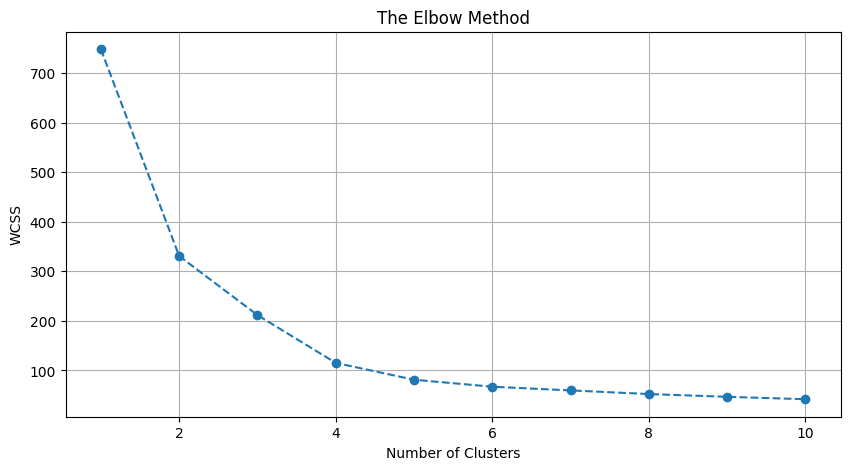

In [13]:
from matplotlib import lines
wcss = []
for i in range(1,11):
  kmeans = KMeans(i,n_init=30,random_state=42)
  kmeans.fit(df_scaled_shopping)
  wcss.append(kmeans.inertia_)

#Plot graph of range  vs inertia
plt.figure(figsize=(10,5))
plt.plot(range(1,11),wcss,marker='o',linestyle='--')
plt.title('The Elbow Method')
plt.grid(True)
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()

In [14]:
#DBSCAN
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN

In [15]:
# 1. Initialize and fit DBSCAN
# Note: eps and min_samples need tuning based on your data scale and distribution
dbscan = DBSCAN(eps=0.5, min_samples=5)

In [16]:

# Fit and predict clusters (-1 represents noise / outliers)
dbscan_clusters = dbscan.fit_predict(df_scaled_shopping.drop(columns=['Cluster'], errors='ignore'))

In [17]:
# 2. Add cluster labels to dataframe
df_scaled_shopping['DBSCAN_Cluster'] = dbscan_clusters

In [18]:
# 3. View cluster distribution
print("Cluster counts ( -1 indicates noise/outliers ):")
print(df_scaled_shopping['DBSCAN_Cluster'].value_counts())

Cluster counts ( -1 indicates noise/outliers ):
DBSCAN_Cluster
 0    190
-1     10
Name: count, dtype: int64


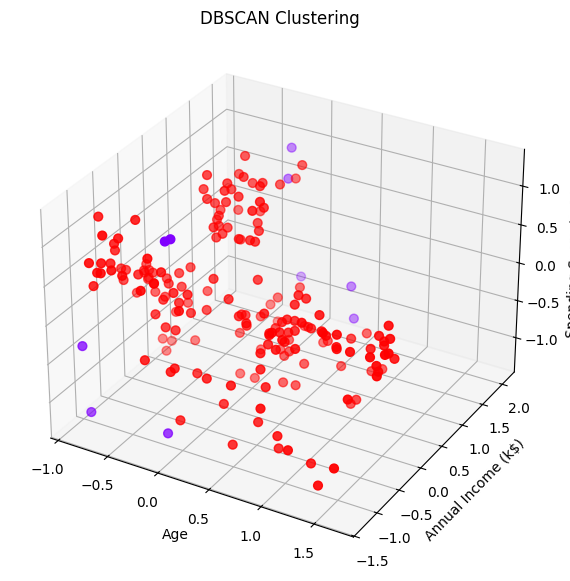

In [20]:
# 4. Visualize in 3D
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(
    df_scaled_shopping['Age'],
    df_scaled_shopping['Annual Income (k$)'],
    df_scaled_shopping['Spending Score (1-100)'],
    c=df_scaled_shopping['DBSCAN_Cluster'],
    cmap='rainbow',
    s=40
)

ax.set_xlabel('Age')
ax.set_ylabel('Annual Income (k$)')
ax.set_zlabel('Spending Score (1-100)')
plt.title('DBSCAN Clustering')
plt.show()